In [1]:
# # %%capture

# # Install the PyBolt package directly from Github
# %pip install git+https://github.com/Maxim-Laletin/PyBolt.git@setup-package

# # Install the torch
# %pip install torch

# # Install pandas
# %pip install pandas

In [2]:
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from PyBolt import cosmology 
from PyBolt import fBE_solver as fBE
import time
import math

from scipy.interpolate import CubicSpline


from cubic_spline import TorchCubicSpline
from pinn import compute_gradients, uniform_sampler, FCN

torch.set_default_dtype(torch.float32)


# Defining functions

NOW WE CAN USE THE COSMOLOGY PACKAGE FOR THE QUANTITIES USED IN THIS CODE. PLEASE CHECK WHICH QUANTITIES ARE USED AND REWRITE THEM AS SOME OF THEM BELOW

In [3]:

Hubble = cosmology.H

gs = cosmology.h_s

gTilde = cosmology.gtilda

HubbleTilde = cosmology.H_t


In [4]:
# The mass of the mother particle (MP)
m1=1
# The mass of the daughter particle (DP)
m2=0.5

# m1 = 1.776 # (tau) GeV
# m2 = 0.10565 # (muon) GeV

# The mass of the DM particle
mDM = 1e-10 # GeV

# PQ symmetry breaking scale
fa = 2e+8 # GeV
# corresponds to the freeze out

# Ratio of the two masses
mu = m2/m1
massRatio=m2/m1

# Number of massless particle degrees of freedom
g_x = 1.0
# Number of MP dofs
g_m1 = 2.0
# Number of DP dofs
g_m2 = 2.0

# Coupling of MP-DP-x
yMDx = 1

# Decay width of MP -> DP + x
Gamma = yMDx**2*m1**3*(1-(m2/m1)**2)**3/64/np.pi/fa**2 # GeV
# Msquared for the decay

Msq= yMDx**2*m1**4*(1 - (m2/m1)**2)**2/4/fa**2 # GeV^2

# Numerical solution:

We calculate the phase-space distribution using PyBolt package

In [5]:
# Create a model of axion phase-space evolution
AxionModel = fBE.Model(m1,mDM,g_x,'b')
# m1 is the mass of the heaviest particle in the reaction

# Create an instance of the DecayToX process class
Decay = fBE.DecayToX(m1,m2,g_m1,Msq,Gamma)

# Create the grid of x and q
N_x = 500 # number of x points
N_q = 200 # number of q points
x0 = 1.0  # starting x value
xf = 20.0 # final x value

q0 = 0.0001 # smallest q value
qf = 20. # biggest q value

# Creating vectors of linearly distributed values of x and q
x_lin = np.linspace(x0,xf,N_x)
q_lin = np.linspace(q0,qf,N_q)

# Assigning the grid (of x and q) to the model
AxionModel.changeGrid(x_lin,q_lin)

# Add the decay collision integral to the model collision term (the only process that we consider)
AxionModel.addCollisionTerm(Decay.collisionTerm)

# Initial distribution
#f0 = np.zeros_like(q_lin)
f0 = AxionModel.equilibriumFunction(q_lin)

# fBE solver options
solver_options = {
    'method': 'BDF', # Implicit backward differentiation formula method of variable order (1-5) - because the equation is stiff
    'atol': 1e-5,   # Absolute tolerance
    'rtol': 1e-3   # Relative tolerance
}

# Solving the fBE
AxionModel.solve_fBE(f0,solver_options)

NumericalFinalDistribution = AxionModel.getSolution()[-1, :]

# Creating the kymograph plot of the solution
# AxionModel.plot2D()

fBE solved in 0.08 seconds


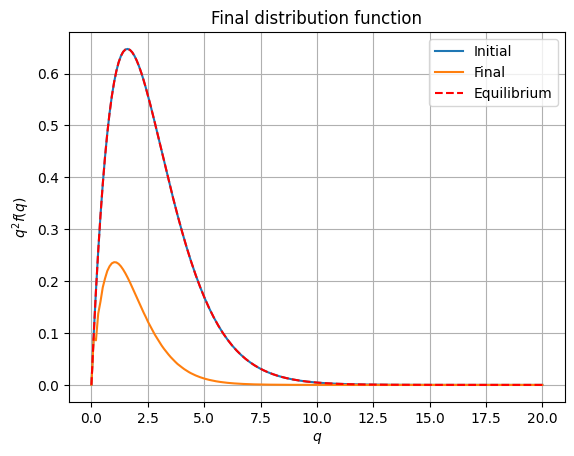

In [6]:
# Plot the initial and final solutions and the equilibrium distribution to compare
plt.figure()
plt.plot(q_lin,f0, label = 'Initial')
plt.plot(q_lin, AxionModel.getSolution()[-1,:], label = 'Final')
plt.plot(q_lin, AxionModel.equilibriumFunction(q_lin),'r--', label = 'Equilibrium')
plt.xlabel(r'$q$')
plt.ylabel(r'$q^2 f(q)$')
plt.title("Final distribution function")
plt.legend(loc="upper right")
plt.grid()
plt.show()

# PINN


In [7]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'


# dof from arXiv:
dof_arr = np.array([
    [0.00, 10.71, 1.00228],
    [0.50, 10.74, 1.00029],
    [1.00, 10.76, 1.00048],
    [1.25, 11.09, 1.00505],
    [1.60, 13.68, 1.02159],
    [2.00, 17.61, 1.02324],
    [2.15, 24.07, 1.05423],
    [2.20, 29.84, 1.07578],
    [2.40, 47.83, 1.06118],
    [2.50, 53.04, 1.04690],
    [3.00, 73.48, 1.01778],
    [4.00, 83.10, 1.00123],
    [4.30, 85.56, 1.00389],
    [4.60, 91.97, 1.00887],
    [5.00, 102.17, 1.00750],
    [5.45, 104.98, 1.00023]
])

# Prepare data
gx = dof_arr[:, 0] - 3  # log10(T/GeV) points
gy = dof_arr[:,1] # g points

hy_np = dof_arr[:, 1] / dof_arr[:, 2]  # h points

# Compute log10(hy)
log_hy = np.log10(hy_np)

# Compute the derivative of the spline (in NumPy)
hslog_spline = CubicSpline(gx, log_hy)
dloghdlogT_spline = hslog_spline.derivative()

gy_spline = CubicSpline(gx,gy)
g_rho = lambda T: gy_spline(np.log10(T))






# Create TorchCubicSpline instances
hslog_spline_torch = TorchCubicSpline(gx, log_hy)
dloghdlogT_spline_torch = hslog_spline_torch.derivative()

def g_tilde_torch(T):
    return (1 / 3) * dloghdlogT_spline_torch(torch.log10(T))

gy_spline_torch=TorchCubicSpline(gx,gy)

def g_rho_torch(T):
    return gy_spline_torch(torch.log10(T))


def Hubble_torch(T):
    return torch.sqrt(8*(np.pi**3)*g_rho_torch(T)/(90))*T**2/mPl

torch.set_printoptions(precision=20)


Tex=torch.tensor(1.12).to(device)
TexNP=Tex.detach().numpy()

mPl = torch.tensor(1e19, dtype=torch.float32).to(device)

Tex.requires_grad=True
print(g_tilde_torch(Tex),gTilde(TexNP))

print(g_rho_torch(Tex),g_rho(TexNP))

print(Hubble_torch(Tex),Hubble(TexNP))
Hubble_torch(Tex)

torch.set_printoptions(precision=2)

tensor(0.05579057035992064650, dtype=torch.float64, grad_fn=<MulBackward0>) 0.055790570359920647
tensor(74.84211078829159191628, dtype=torch.float64, grad_fn=<AddBackward0>) 74.84211078829159
tensor(1.80159684616752631581e-18, dtype=torch.float64, grad_fn=<DivBackward0>) 1.801596842655574e-18


In [8]:
def feq(q):
  return q**2/(torch.exp(q) - 1.0)

def MS_loss_function(residual):
    return torch.mean(residual**2)
  
def InitialCondition_residual(f,x,q):
  return f(x,q)-feq(q)

def smooth_max(inputs, dim, alpha=10):
    return (torch.logsumexp(alpha * inputs, dim=dim)) / alpha
  
def smooth_abs(x, epsilon=1e-10):
    return torch.sqrt(x**2 + epsilon)


def BE_residue_old(f,x,q,fa):
  gTildeInternal=g_tilde_torch(m1/x)
  HubbleTildeInternal=Hubble_torch(m1/x)

  # Msq= yMDx**2*m1**4*(1 - (m2/m1)**2)**2/4/fa**2 # GeV^2
  Elim1 = torch.max(torch.stack([x, x*massRatio+q, x**2*(1 + 4*q**2/(x**2*(1-massRatio**2)) - (1-massRatio**2) )/4/q],dim=1),1).values
  Elim2 = torch.max(torch.stack([x-q, x*massRatio, x**2/4/q],dim=1),1).values
  
  # Elim1 = smooth_max(torch.stack([x, x*massRatio+q, x**2*(1 + 4*q**2/(x**2*(1-massRatio**2)) - (1-massRatio**2) )/4/q],dim=1),1).values
  # Elim2 = smooth_max(torch.stack([x-q, x*massRatio, x**2/4/q],dim=1),1).values
  
  df_dx, df_dq=compute_gradients(f,x,q)


  q2CollTerm = (((2*x*Msq/16/torch.pi/g_x/q**2)*(torch.log((1+torch.exp(-Elim1))/(1+torch.exp(-Elim2))))))*(f(x,q) - feq(q))
  free_BE=df_dx-(gTildeInternal*(df_dq*q - 2*f(x,q)))/x
    
  return free_BE+q2CollTerm/HubbleTildeInternal/x

In [ ]:
def BE_residue(f,x,q,fa):
  gTildeInternal=g_tilde_torch(m1/x)
  HubbleTildeInternal=Hubble_torch(m1/x)
  eq=torch.sqrt((mDM*x/m1)**2+q**2)

  Msq= yMDx**2*m1**4*(1 - (m2/m1)**2)**2/4/fa**2 # GeV^2
  # Elim1 = torch.max(torch.stack([x, x*massRatio+q, x**2*(1 + 4*q**2/(x**2*(1-massRatio**2)) - massRatio**2 )/4/q],dim=1),1).values
  # Elim2 = torch.max(torch.stack([x-q, x*massRatio, x**2/4/q],dim=1),1).values
  Elim1 = smooth_max(torch.stack([x, x*massRatio+q, x**2*(1 + 4*q**2/(x**2*(1-massRatio**2)) - (1-massRatio**2) )/4/q],dim=1),dim=1)
  Elim2 = smooth_max(torch.stack([x-q, x*massRatio, x**2/4/q],dim=1),dim=1)
  
  
  df_dt, df_dq=compute_gradients(f,x,q)
  
  #from PyBolt:
  CollTerm=(2 * g_m1 * Msq * x / m1 / 8 / torch.pi / q**3) * (torch.log((1 + torch.exp(-Elim1)) / (1 + torch.exp(-Elim2)))) * (f(x,q) - feq(q))
  
  free_BE=x*df_dt-(gTildeInternal*(df_dq*q - 2*f(x,q))) #multiply both sides of BE by x
    
  return free_BE+(q**2)*CollTerm/(2*g_x*eq)/HubbleTildeInternal
  

  # free_BE=df_dt-(gTildeInternal*(df_dq*q - 2*f(x,q)))/x
    
  # return free_BE+(q**2)*CollTerm/(2*g_x*eq)/HubbleTildeInternal/x



# def fex(x,y):
#   return x+y

# # xex=torch.Tensor([1.1,2.2])
# # qex=torch.Tensor([10.1,8.3])

# xex=torch.rand(10)
# qex=torch.rand(10)
# torch.set_printoptions(precision=5)

# print(BE_residue_old(fex,xex,qex,1),BE_residue(fex,xex,qex,1))
# torch.set_printoptions(precision=2)


# Learning

In [10]:
class TrainingBoltzmaNN:
    def __init__(self,
                 hidden_width,
                 batch_size,
                 num_epochs,
                 patience,
                 optimizer=torch.optim.Adam,
                 scheduler=ReduceLROnPlateau,
                 collocation_number_plot=200,
                 learning_rate=1e-2,
                 **kwargs):
        # Initialize model, optimizer, scheduler, and other settings
        self.model = FCN(
            input_dim=2,
            output_dim=1,
            hidden=(hidden_width, hidden_width),
            normalize=True,
            x_min=[x0, q0],
            x_max=[xf, qf],
            activations=torch.nn.Tanh()
        )
        self.optimizer = optimizer(self.model.parameters(), lr=learning_rate, **kwargs)
        self.scheduler = scheduler(
            self.optimizer,
            factor=0.5,
            patience=patience,
            min_lr=1e-8,
            threshold=1e-5,
            eps=0
        )
        
        # Training parameters
        self.num_epochs = num_epochs
        self.batch_size = batch_size
        self.collocation_number_plot = collocation_number_plot
        self.plotting_step = 1000  
        # self.resampling_interval = 100  

        # History trackers
        self.loss_history = []  
        self.MSE_numerical = np.array([])
        self.history_distributions_final = []
        self.history_distributions_initial = []

        # Plotting variables
        self.q_values = torch.linspace(q0, qf, steps=collocation_number_plot).view(collocation_number_plot, 1).to(device)
        self.x_values_fin = torch.ones_like(self.q_values) * xf
        self.x_values_ini = torch.ones_like(self.q_values)
        self.q_values.requires_grad = True
        self.x_values_fin.requires_grad = True
        self.x_values_ini.requires_grad = True
        self.q_plot_values = self.q_values.cpu().detach().numpy()  

    def sample_points(self, q_min, q_max, x_min, x_max):
        x_samples = uniform_sampler(self.batch_size, [x_min], [x_max])  
        q_samples = uniform_sampler(self.batch_size, [q_min], [q_max])  
        x_grid, q_grid = torch.meshgrid(x_samples.squeeze(), q_samples.squeeze(), indexing="ij")
        xq_meshgrid = torch.stack((x_grid, q_grid), dim=-1).reshape(-1, 2)  
        xq_meshgrid.requires_grad = True
        return xq_meshgrid[:, 0].view(-1, 1).to(device), xq_meshgrid[:, 1].view(-1, 1).to(device)

    def train(self, physics_weight, positivity_weight, bc_weight, initialC_weight):
        self.model.train().to(device)
        for epoch in range(self.num_epochs):
            self.optimizer.zero_grad()
            x_grid, q_grid = self.sample_points(q0, qf, x0, xf)

            # Compute boundary condition losses
            boundary_loss_start = MS_loss_function(self.model(x_grid, torch.zeros_like(q_grid)))  
            boundary_loss_end = MS_loss_function(
                self.model(x_grid, qf * torch.ones_like(q_grid)) #- qf**2 / (np.exp(qf) - 1)
            )  
            bc_loss = bc_weight * (boundary_loss_start + boundary_loss_end)
            
            # Compute initial condition loss
            initial_condition_loss = initialC_weight * MS_loss_function(
                InitialCondition_residual(self.model, x0*torch.ones_like(x_grid), q_grid)
            ) 

            # Compute physics loss
            equation_residual_loss = physics_weight * MS_loss_function(
                BE_residue(self.model, x_grid, q_grid, fa)
            )  
            
            # Compute positivity constraint
            positivity_loss = positivity_weight * MS_loss_function(
                smooth_abs(self.model(x_grid, q_grid)) - self.model(x_grid, q_grid)
            )
            
            # Total loss and backward pass
            total_loss = equation_residual_loss + bc_loss + initial_condition_loss + positivity_loss  
            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), max_norm=10.0)
            self.scheduler.step(total_loss)
            self.optimizer.step()
            
            # Track losses
            current_lr = self.optimizer.param_groups[0]["lr"]
            self.loss_history.append({
                'boundary': bc_loss.item(),
                'initial': initial_condition_loss.item(),
                'physics': equation_residual_loss.item(),
                'weighted_sum': total_loss.item(),
                'last LR': current_lr
            })
            
            if epoch % self.plotting_step == 0 and epoch!=0:
                print(self.loss_history[-1])
                self.update_mse_numerical(epoch)
                self.record_distribution_history()

        self.loss_history = pd.DataFrame(self.loss_history)

    def update_mse_numerical(self, epoch):
        predicted_final_distribution = self.model(self.x_values_fin, self.q_values).cpu().detach().numpy().reshape(-1) 
        rmse = np.sqrt(np.mean((NumericalFinalDistribution - predicted_final_distribution) ** 2))  
        self.MSE_numerical = np.append(self.MSE_numerical, rmse)
        print(f"Epoch {epoch}: MSE wrt numerical = {rmse}")

    def record_distribution_history(self):
        predicted_final = self.model(self.x_values_fin, self.q_values).cpu().detach()  
        predicted_initial = self.model(self.x_values_ini, self.q_values).cpu().detach()  
        self.history_distributions_final.append(predicted_final)
        self.history_distributions_initial.append(predicted_initial)

    def plot_steps(self):
        num_plots = len(self.history_distributions_final)
        rows = math.ceil(num_plots / 2)  # number of rows needed
        fig, axes = plt.subplots(rows, 2, figsize=(10, 4 * rows))  # Adjust the figure size for readability

        axes = axes.flatten()  # Flatten the 2D array of axes for easier indexing

        for epoch_index, (predicted_final, predicted_initial) in enumerate(
            zip(self.history_distributions_final, self.history_distributions_initial)
        ):
            ax = axes[epoch_index]
            ax.plot(self.q_plot_values, predicted_final, label='PINN final', color='r')
            ax.plot(self.q_plot_values, predicted_initial, label='PINN initial', color='g')
            ax.plot(q_lin, NumericalFinalDistribution, 'r--', label='Numerical, final')
            ax.plot(q_lin, f0, 'g--', label='Numerical, initial')
            ax.set_xlabel("q")
            ax.set_ylabel("q^2 f(q)")
            ax.set_title(f"#epochs={(epoch_index+1) * self.plotting_step}")
            ax.legend()

        # Hide unused subplots if any
        for i in range(epoch_index + 1, len(axes)):
            axes[i].axis('off')

        plt.suptitle("Prediction vs Actual Values", y=1.02)
        plt.tight_layout()
        plt.show()


    def plot_learning_data(self):
        q_plot = self.q_values.cpu().detach().numpy()
        Loss_of_q = torch.mean(
            BE_residue(self.model, self.x_values_fin, self.q_values,fa) ** 2, dim=1
        ).cpu().detach().numpy()
        Loss_of_x = torch.mean(
            BE_residue(self.model, self.x_values_ini, self.q_values,fa) ** 2, dim=1
        ).cpu().detach().numpy()

        _, ax = plt.subplots(1, 2, figsize=(10, 4))
        ax[0].plot(q_plot, Loss_of_q, 'b--', label='Physics loss in q')
        ax[1].plot(q_plot, Loss_of_x, 'b--', label='Physics loss in x')
        for a in ax:
            a.legend()
        plt.tight_layout()
        plt.show()
        
        self.plot_error()

    def plot_error(self):
        plt.plot(
            np.linspace(0, self.num_epochs, self.MSE_numerical.size),
            self.MSE_numerical,
            label='MSE wrt numerical'
        )
        plt.legend()
        plt.show()


{'boundary': 0.0016555273905396461, 'initial': 0.03012964501976967, 'physics': 0.003095319921616265, 'weighted_sum': 0.0348805478240769, 'last LR': 0.01}
Epoch 1000: MSE wrt numerical = 0.06178114129365508
{'boundary': 0.007855866104364395, 'initial': 0.018836531788110733, 'physics': 0.03125078956389088, 'weighted_sum': 0.05799555687069996, 'last LR': 0.01}
Epoch 2000: MSE wrt numerical = 0.06200226745041156
{'boundary': 0.00673892255872488, 'initial': 0.012230862863361835, 'physics': 0.004739501740819543, 'weighted_sum': 0.02370928716290626, 'last LR': 0.01}
Epoch 3000: MSE wrt numerical = 0.06281706017079933
{'boundary': 0.0011561046121641994, 'initial': 0.009197218343615532, 'physics': 0.002223387551150147, 'weighted_sum': 0.012591019657103963, 'last LR': 0.01}
Epoch 4000: MSE wrt numerical = 0.07054151734413337
{'boundary': 0.0020246882922947407, 'initial': 0.003656702348962426, 'physics': 0.004297378770270046, 'weighted_sum': 0.009978769411527257, 'last LR': 0.005}
Epoch 5000: MSE

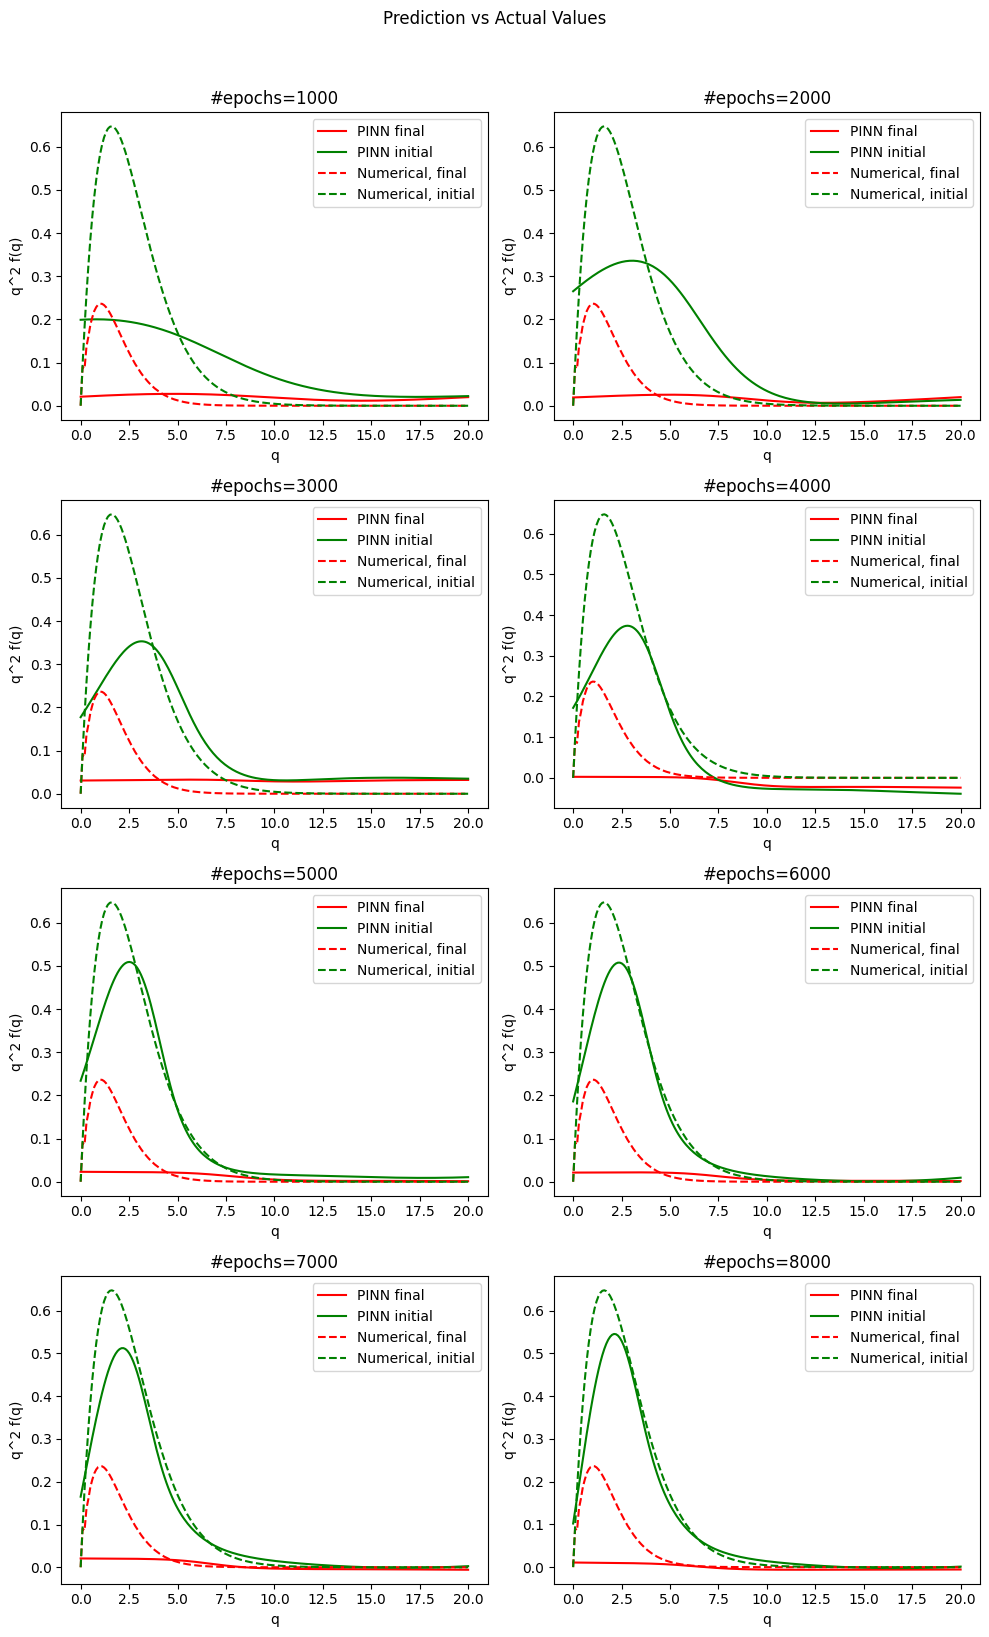

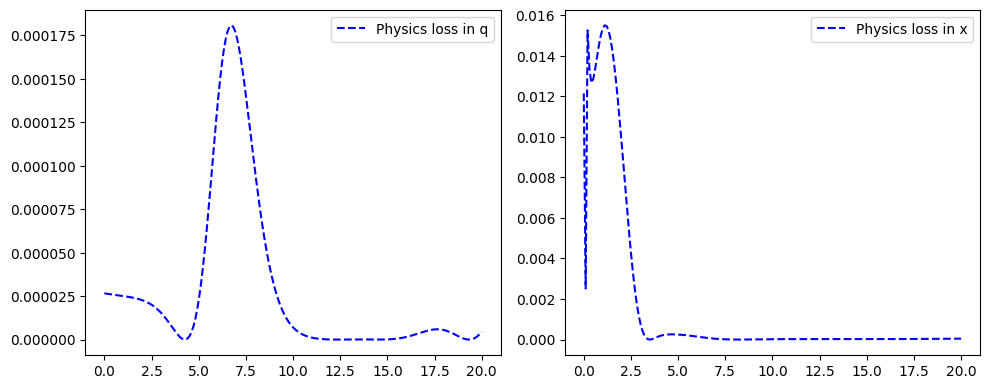

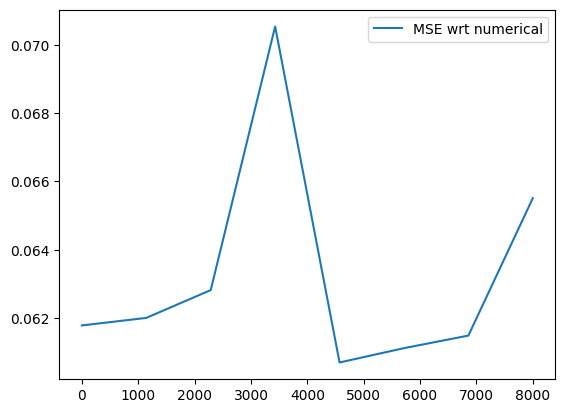

In [11]:
# Initialize the TrainingBoltzmaNN instance with the specified parameters
train1 = TrainingBoltzmaNN(
    hidden_width=30,
    batch_size=25,
    num_epochs=8001,
    patience=1000,
    collocation_number_plot=N_q
)

# Train the network and measure the training time
start_time = time.time()
train1.train(physics_weight=5, positivity_weight=1, bc_weight=1, initialC_weight=1)
end_time = time.time()
print('Learning time:', end_time - start_time, "\n\n")

# Plot the steps and learning data
train1.plot_steps()
train1.plot_learning_data()


In [12]:
# # Initialize the TrainingBoltzmaNN instance with the specified parameters
# train1 = TrainingBoltzmaNN(
#     hidden_width=32,
#     batch_size=40,
#     num_epochs=16001,
#     patience=2000,
#     collocation_number_plot=N_q
# )

# # Train the network and measure the training time
# start_time = time.time()
# train1.train(physics_weight=40, positivity_weight=1, bc_weight=1, initialC_weight=1)
# end_time = time.time()
# print('Learning time:', end_time - start_time, "\n\n")

# # Plot the steps and learning data
# train1.plot_steps()
# train1.plot_learning_data()


In [13]:
# class TrainingBoltzmaNN:
#     def __init__(
#         self,
#         # hidden_width,
#         collocation_number_plot=100,
#     ):
#         # Initialize the neural network model
#         self.model_f = FCN(
#             input_dim=2,
#             output_dim=1,
#             hidden=(hidden_width, hidden_width),
#             normalize=True,
#             x_min=[x0, q0],
#             x_max=[xf, qf],
#             activations=nn.Tanh(),
#         )
#         self.model_f.to(device)
#         self.collocation_number_plot = collocation_number_plot

#     def train(self, num_epochs,batch_size,physics_weight,bc_weight=1,positivity_weight=1,
#         learning_rate=1e-2,patience=1000,optimizer_class=torch.optim.Adam, scheduler_class=ReduceLROnPlateau,
#         ):
#         self.model_f.train()
#         history = []
#         mse_numerical = []
        
#         # Set up optimizer and scheduler
#         self.optimizer = optimizer_class(
#             self.model_f.parameters(), lr=learning_rate
#         )
#         self.scheduler = scheduler_class(
#             self.optimizer,
#             factor=0.5,
#             patience=patience,
#             min_lr=1e-5,
#             threshold=1e-5,
#             eps=0,
#         )

#         # Prepare plotting data
#         q_values = torch.linspace(
#             q0, qf, steps=self.collocation_number_plot
#         ).reshape(-1, 1).to(device)
#         x_values_fin = torch.full_like(q_values, xf).to(device)
#         x_values_ini = torch.full_like(q_values, x0).to(device)
#         X_plot = q_values.cpu().detach().numpy()
#         NumericalFinalDistribution=AxionModel.getSolution()[-1,:]

#         for epoch in range(num_epochs):
#             self.optimizer.zero_grad()

#             # Sample collocation points for PDE residual
#             x_sample = uniform_sampler(batch_size, [x0], [xf]).to(device)
#             q_sample = uniform_sampler(batch_size, [q0], [qf]).to(device)
#             x_grid, q_grid = torch.meshgrid(
#                 x_sample.squeeze(), q_sample.squeeze(), indexing="ij"
#             )
#             x_grid = x_grid.reshape(-1, 1).requires_grad_(True)
#             q_grid = q_grid.reshape(-1, 1).requires_grad_(True)

#             # Compute PDE residual and loss
#             physics_residual = FullBoltzmannEquation_residual_torch(
#                 self.model_f, x_grid, q_grid
#             )
#             physics_loss = physics_loss_function(physics_residual)
#             physics_loss_weighted = physics_weight * physics_loss

#             # Sample points for boundary conditions at q = q0 and q = qf
#             x_bc = uniform_sampler(batch_size, [x0], [xf]).to(device)
#             q_bc_0 = torch.full((batch_size, 1), q0).to(device)
#             q_bc_f = torch.full((batch_size, 1), qf).to(device)
#             bc_loss_0 = physics_loss_function(self.model_f(x_bc, q_bc_0))
#             bc_loss_f = physics_loss_function(self.model_f(x_bc, q_bc_f))
#             bc_loss = bc_loss_0 + bc_loss_f

#             # Sample points for initial condition at x = x0
#             q_ini = uniform_sampler(batch_size, [q0], [qf]).to(device)
#             x_ini = torch.full((batch_size, 1), x0).to(device)
#             ini_residual = InitialCondition_residual(
#                 self.model_f, x_ini, q_ini
#             )
#             ini_loss = physics_loss_function(ini_residual)

#             # Total boundary condition loss
#             bc_total_loss = bc_weight * (bc_loss + ini_loss)

#             # Enforce positivity of the solution
#             output = self.model_f(x_grid, q_grid)
#             positivity_loss = positivity_weight * physics_loss_function(
#                 torch.relu(-output)
#             )

#             # Total loss
#             total_loss = physics_loss_weighted + bc_total_loss + positivity_loss
#             total_loss.backward()

#             # Update optimizer and scheduler
#             self.optimizer.step()
#             self.scheduler.step(total_loss)

#             # Logging
#             current_lr = self.optimizer.param_groups[0]["lr"]
#             self.losses = {
#                 "boundary": bc_total_loss.item(),
#                 "physics": physics_loss_weighted.item(),
#                 "positivity": positivity_loss.item(),
#                 "total_loss": total_loss.item(),
#                 "learning_rate": current_lr,
#             }
#             history.append(self.losses)

#             # Compute MSE with numerical solution every 500 epochs
#             if epoch % 500 == 0:
#                 with torch.no_grad(): #prevent unnecessary calculation of derivatives
#                     nn_final = self.model_f(
#                         x_values_fin, q_values
#                     ).cpu().numpy().squeeze()
#                 mse = np.sqrt(
#                     np.mean((NumericalFinalDistribution - nn_final) ** 2)
#                 )
#                 mse_numerical.append(mse)
#                 print(f"Epoch {epoch}, Losses: {self.losses}")
#                 print(f"MSE w.r.t numerical solution: {mse}")

#             # Plot results every 1000 epochs
#             if epoch % 1000 == 0 and epoch != 0:
#                 with torch.no_grad():
#                     nn_final = self.model_f(
#                         x_values_fin, q_values
#                     ).cpu().numpy().squeeze()
#                     nn_initial = self.model_f(
#                         x_values_ini, q_values
#                     ).cpu().numpy().squeeze()

#                 plt.figure(figsize=(5, 3))
#                 plt.plot(X_plot, nn_final, label="PINN final", color="g")
#                 plt.plot(X_plot, nn_initial, label="PINN initial", color="r")
#                 plt.plot(q_lin, NumericalFinalDistribution, label = 'Numerical final')
#                 plt.plot(q_lin, AxionModel.getSolution()[0,:], label = 'Numerical initial')
                
#                 plt.xlabel("q")
#                 plt.ylabel("q^2 f(q)")
#                 plt.title(f"Prediction vs Actual Values at Epoch {epoch}")
#                 plt.legend()
#                 plt.show()

#         # Convert history to DataFrame for analysis
#         history_df = pd.DataFrame(history)
#         mse_numerical = np.array(mse_numerical)

#         # Plot relative error
#         plt.figure(figsize=(5, 3))
#         relative_error = np.abs(nn_final / NumericalFinalDistribution)
#         plt.semilogy(X_plot, relative_error, label="Relative Error", color="g")
#         plt.xlabel("q")
#         plt.ylabel("Relative Error")
#         plt.title(f"Relative Error at Epoch {epoch}")
#         plt.legend()
#         plt.show()

#         # Plot physics loss over epochs
#         plt.figure(figsize=(5, 3))
#         plt.semilogy(history_df["physics"], color="blue")
#         plt.xlabel("Epoch")
#         plt.ylabel("Physics Loss")
#         plt.title("Physics Loss over Epochs")
#         plt.show()

#         # Plot MSE over epochs
#         epochs = np.arange(0, num_epochs, 500)
#         plt.figure(figsize=(5, 3))
#         plt.semilogy(epochs, mse_numerical, color="red")
#         plt.xlabel("Epoch")
#         plt.ylabel("MSE")
#         plt.title("MSE w.r.t Numerical Solution over Epochs")
#         plt.show()

In [14]:
# class TrainingBoltzmaNN:
#   def __init__(self,
#                hiddenWidth,
#                batch_size,
#                num_epochs,
#                patience,
#                optimizer=torch.optim.Adam,
#                scheduler=ReduceLROnPlateau,
#                collocation_number_plot=200,
#                bc_weight=0.1,
#                physics_weight=50,
#                learning_rate=1e-3,
#                **kwargs):
#     self.model_f=FCN(2,1,hidden=(hiddenWidth,hiddenWidth), normalize=True, x_min=[x0,q0], x_max=[xf, qf],activations=torch.nn.Tanh())
#     parameters = [*self.model_f.parameters()]


#     # for name, param in self.model_f.named_parameters():
#     #   if param.requires_grad:
#     #     print(name, param.data,param.dtype)

#     self.optimizer=optimizer(parameters, lr=learning_rate,**kwargs) #,weight_decay=1e-5,momentum=0.9,dampening=0.1
#     self.num_epochs=num_epochs
#     self.batch_size=batch_size
#     self.physics_weight=physics_weight
#     self.bc_weight=bc_weight
#     self.collocation_number_plot=collocation_number_plot
#     self.scheduler = scheduler(self.optimizer, factor=0.1, patience=patience, min_lr=1e-5,threshold=1e-5,eps=0) #,threshold =1e-6
#     self.history=[]
#     self.MSE_numerical=np.array([])
#     self.history_distributions_final=[]
#     self.history_distributions_initial=[]
#     self.plotting_step=1000
#     self.epoch_sampling_change=100

#     #var for plotting
#     self.q_values=torch.reshape(torch.linspace(q0, qf, steps=self.collocation_number_plot),(self.collocation_number_plot,1))
#     self.x_values_fin = torch.reshape(torch.ones_like(self.q_values)*xf,(self.collocation_number_plot,1)).to(device)
#     self.x_values_ini = torch.reshape(torch.ones_like(self.q_values)*1,(self.collocation_number_plot,1)).to(device)
#     self.q_values=self.q_values.to(device)
#     self.x_values_ini=self.x_values_ini.to(device)
#     self.X_plot=self.q_values.cpu().detach().numpy()
#     self.x_values_fin.requires_grad=True
#     self.q_values.requires_grad=True



#   def SamplePoints(self,q_min,q_max,x_min,x_max):
#         x_sample = uniform_sampler(self.batch_size, [x_min], [x_max])
#         q_sample = uniform_sampler(self.batch_size, [q_min], [q_max])#.to(device)
#         x_gridS,q_gridS=torch.meshgrid(torch.squeeze(x_sample), torch.squeeze(q_sample),indexing="ij")
#         xq_grid=torch.reshape(torch.stack(((x_gridS, q_gridS)), dim=-1),(self.batch_size**2,2))
#         xq_grid.requires_grad=True
#         return torch.reshape(xq_grid[:,0],(self.batch_size**2,1)).to(device), torch.reshape(xq_grid[:,1],(self.batch_size**2,1)).to(device)



#   def train(self):
#     self.model_f.train().to(device)
    
#     for epoch in range(self.num_epochs):

#         self.optimizer.zero_grad()  # Clear gradients before next loss is computed

#         x_grid, q_grid =self.SamplePoints(q0,qf,x0,xf)
#         # if epoch>self.num_epochs-self.epoch_sampling_change: x_grid, q_grid =self.SamplePoints(q0,4,x0,xf)





#         #boundary conditions at q=0,12

#         #check if other BC is necessary, what if we drop both?
#         bc_loss1=physics_loss_function(self.model_f(x_grid,torch.zeros_like(q_grid)))
#         bc_loss2=physics_loss_function(self.model_f(x_grid,qf*torch.ones_like(q_grid))-qf**2/(np.exp(qf)-1)*torch.ones_like(self.model_f(x_grid,qf*torch.ones_like(q_grid)).to(device))) #it approaches value of feq(q=12), but I can also set feq(q=12, x=xf)?
#         # bc_loss2=physics_loss_function(self.model_f(x_grid,qf*torch.ones_like(q_grid))-0)

#         bc_loss=bc_loss1+bc_loss2
#         #initial conidtion
#         ini_residual=InitialCondition_residual(self.model_f,x_grid,q_grid)
#         ini_loss=physics_loss_function(ini_residual)
#         BC_loss=self.bc_weight*bc_loss+ini_loss #is it ok?



#         # PDE
#         physics_residual =FullBoltzmannEquation_residual_torch(self.model_f, x_grid,q_grid)
#         # devide loss by the derivative of q

#         physics_loss = physics_loss_function(physics_residual)
#         physics_loss_weighted = self.physics_weight * physics_loss

#         #positivity of distribution
#         loss_positivity=10*physics_loss_function(torch.abs(self.model_f(x_grid,q_grid))-self.model_f(x_grid,q_grid))

#         loss =  physics_loss_weighted+BC_loss+loss_positivity
#         loss.backward()
#         # torch.nn.utils.clip_grad_norm_(parameters, 10.) # improves training stability
#         current_lr = self.optimizer.param_groups[0]["lr"]

#         losses = {
#             'boundary': BC_loss.item(),
#             'physics': physics_loss_weighted.item(),
#             'weighted_sum': loss.item(),
#             'last LR': current_lr
#             }

#         # historyTotalLoss=np.append(historyTotalLoss,loss.item())
#         # mean_of_last_losses=np.mean(historyTotalLoss[-100:])
#         # scheduler.step(mean_of_last_losses)

#         self.scheduler.step(loss)


#         self.optimizer.step()  # Update weights
#         self.history.append(losses)

#         if epoch % 500 == 0 : #and epoch != 0
#           self.MSE_numerical=np.append(self.MSE_numerical,np.sqrt(np.mean((NumericalFinalDistribution-np.reshape(self.model_f(self.x_values_fin, self.q_values).cpu().detach().numpy(),self.collocation_number_plot))**2)))
#           print(epoch, losses)
#           print('MSE wrt numerical:', self.MSE_numerical[-1])
#         if epoch % self.plotting_step == 0 and epoch != 0:
#           self.MSE_numerical=np.append(self.MSE_numerical,np.sqrt(np.mean((NumericalFinalDistribution-np.reshape(self.model_f(self.x_values_fin, self.q_values).cpu().detach().numpy(),self.collocation_number_plot))**2)))

#           NN_final = self.model_f(self.x_values_fin, self.q_values)
#           NN_initial = self.model_f(self.x_values_ini, self.q_values)
#           self.history_distributions_final=self.history_distributions_final+[NN_final.cpu().detach()]
#           self.history_distributions_initial=self.history_distributions_initial+[NN_initial.cpu().detach()]
#     self.history = pd.DataFrame(self.history)


#   def PlotSteps(self):
#     number_density_num=integrate.cumulative_trapezoid(NumericalFinalDistribution.reshape(self.collocation_number_plot),q_lin, initial=0)
#     for i in range(len(self.history_distributions_final)):
#       number_density_NN=integrate.cumulative_trapezoid(self.history_distributions_final[i].reshape(self.collocation_number_plot), self.X_plot.reshape(self.collocation_number_plot), initial=0)

#       plt.plot(self.X_plot, self.history_distributions_final[i],label='PINN final',color='g')
#       plt.plot(self.X_plot, self.history_distributions_initial[i],label='PINN initial',color='r')
#       plt.plot(q_lin,NumericalFinalDistribution,'g--',label='Numerical, final')
#       plt.plot(q_lin,f0,'b--',label='Numerical, initial')
      

#       plt.xlabel("q")
#       plt.ylabel("q^2 f(q)")
#       plt.title(f"Prediction vs Actual Values #epochs={(i+1)*self.plotting_step}")
#       plt.legend()
#       plt.show()
#       print("number density of NN=",number_density_NN[-1],",  number density of numerical=",number_density_num[-1], " relative difference=",np.abs(number_density_NN[-1]-number_density_num[-1])/number_density_NN[-1])
#       print('MSE wrt numerical:', self.MSE_numerical[i],"\n\n")





#   def PlotLearningData(self):

#     q_values=torch.reshape(torch.linspace(q0, qf, steps=self.collocation_number_plot),(self.collocation_number_plot,1))
#     x_values=torch.reshape(torch.linspace(x0, xf, steps=self.collocation_number_plot),(self.collocation_number_plot,1)).to(device)
#     x_values_fin = torch.reshape(torch.ones_like(q_values)*xf,(self.collocation_number_plot,1)).to(device)
#     x_values_ini = torch.reshape(torch.ones_like(q_values)*1,(self.collocation_number_plot,1)).to(device)
#     q_values=q_values.to(device)
#     x_values_ini=x_values_ini.to(device)
#     X_plot=q_values.cpu().detach().numpy()
#     q_values.requires_grad=True
#     x_values_fin.requires_grad=True
#     x_values.requires_grad=True


#     q_value_example=torch.reshape(torch.ones_like(q_values)*3,(self.collocation_number_plot,1)).to(device)
#     q_value_example.requires_grad=True

#     Loss_of_q=torch.mean(FullBoltzmannEquation_residual_torch(self.model_f, x_values_fin,q_values)**2,1).cpu().detach().numpy()


#     Loss_of_x=torch.mean(self.physics_weight*FullBoltzmannEquation_residual_torch(self.model_f, x_values,q_value_example)**2,1).cpu().detach().numpy()


#     # plt.plot(X_plot,Loss_of_q,'b--',label='physics loss in q')
#     # plt.legend()
#     # plt.show()
#     # plt.plot(X_plot,Loss_of_x,'b--',label='physics loss in x')
#     # plt.legend()
#     # plt.show()
#     fig, ax = plt.subplots(1, 2, figsize=(12, 6))  # Adjust figsize as needed

# # Plot the first set of data on the first subplot
#     ax[0].plot(X_plot, Loss_of_q, 'b--', label='physics loss in q')
#     ax[0].legend()
#     ax[0].set_title('Physics Loss in q')  # Optionally set a title for the subplot

# # Plot the second set of data on the second subplot
#     ax[1].plot(x_values.cpu().detach().numpy(), Loss_of_x, 'b--', label='physics loss in x')
#     ax[1].legend()
#     ax[1].set_title('Physics Loss in x')  # Optionally set a title for the subplot

# # Display the figure
#     plt.tight_layout()  # Adjust layout to prevent overlap
#     plt.show()


# #add other losses as a fucntion of q

#     # plt.show()

#     self.MSE_numerical=pd.DataFrame(self.MSE_numerical)
#     NN_final = self.model_f(x_values_fin, q_values)
#     NN_initial = self.model_f(x_values_ini, q_values)
#     NN_final_plot=NN_final.cpu().detach().numpy()
#     NN_initial_plot=NN_initial.cpu().detach().numpy()

#     plt.semilogy(X_plot, abs(NN_final_plot/torch.reshape(torch.tensor(NumericalFinalDistribution),(self.collocation_number_plot,1)).tolist()),label='PINN final/numerical final',color='g')
#           # Add labels and title
#     plt.xlabel("q")
#     plt.ylabel("q^2 f(q)")
#     plt.title(f"Relative error at #epochs={self.num_epochs}")
#     plt.legend()
#     plt.show()

#     #add plots with x
#     plt.semilogy(self.history['physics'],color='blue',label='physics loss')
#     plt.semilogy(self.history['boundary'],color='red',label='BC+IC loss')
#     plt.semilogy(self.history['weighted_sum'],color='black',label='total loss')
#     plt.legend()
#     plt.show()


#     plt.semilogy(np.linspace(0,self.num_epochs,self.MSE_numerical.size),self.MSE_numerical,color='red',label='MSE wrt numerical') #change so that x is linspace
#     plt.legend()
#     plt.show()
# train1=TrainingBoltzmaNN(hiddenWidth=32,batch_size=25,physics_weight=10,bc_weight=1,num_epochs=4001,patience=1000,collocation_number_plot=200)

# start_time = time.time()
# train1.train()
# end_time = time.time()
# print('learning time:', end_time-start_time,"\n\n")
# train1.PlotSteps()
# train1.PlotLearningData()